In [2]:
import numpy as np
import barnaba as bb
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysis.analysis import *
from sklearn.decomposition import PCA


/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/hbonds/hbond_autocorrel.py:54: DeprecationWarning: This module was moved to MDAnalysis.analysis.hydrogenbonds.hbond_autocorrel; hbonds.hbond_autocorrel will be removed in 3.0.0.
  warnings.warn(wmsg, category=DeprecationWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/hole2/__init__.py:50: UserWarning: Please install the mdahole2 mdakit to use it in MDAnalysis.
More details can be found here: https://www.mdanalysis.org/mdahole2/getting_started.html
  warnings.warn(wmsg, category=UserWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/psa.py:72: UserWarning: Please install the PathSimAnalysis mdakit to use it in MDAnalysis.
More details can be found here: https://www.mdanalysis.org/PathSimAnalysis/getting_started.html
  warnings.warn(wmsg, category=UserWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/p

## Bound Conformation 1 with L10



run 1 - files

In [4]:
traj_1 = "run_1/md05_fix_skip_5.xtc" 
top_1 = "run_1/md05.gro"      
ref_1 = "run_1/md04.gro"

run 2 - files

In [3]:
traj_2 = "run_2/md05_fix_skip_5.xtc"
top_2 = "run_2/md05.gro"
ref_2 = "run_2/md04.gro"

run 3 - files

In [5]:
traj_3 = "run_3/md05_fix_skip_5.xtc"
top_3 = "run_3/md05.gro"
ref_3 = "run_3/md04.gro"

### eRMSD

In [30]:
ermsd_1 = bb.ermsd(ref_1,traj_1,topology=top_1)

# Loaded reference run_1/md04.gro 
# Loaded target run_1/md05_fix_skip_5.xtc 
# Skipping unknown residue L1075 
# Skipping unknown residue L1075 


In [31]:
ermsd_2 = bb.ermsd(ref_2,traj_2,topology=top_2)

# Loaded reference run_2/md04.gro 
# Loaded target run_2/md05_fix_skip_5.xtc 
# Skipping unknown residue L1075 
# Skipping unknown residue L1075 


In [32]:
ermsd_3 = bb.ermsd(ref_3,traj_3,topology=top_3)

# Loaded reference run_3/md04.gro 
# Loaded target run_3/md05_fix_skip_5.xtc 
# Skipping unknown residue L1075 
# Skipping unknown residue L1075 


### MD universe


In [6]:
universe_1 = mda.Universe(top_1, traj_1)

In [7]:
universe_2 = mda.Universe(top_2, traj_2)

In [8]:
universe_3 = mda.Universe(top_3, traj_3)

### RMSD - for RNA

Taking as reference heavy atoms

In [33]:
rmsd_RNA_1 = rms.RMSD(universe_1, universe_1, select="nucleic and not name H*",weights="mass")
rmsd_RNA_1.run()

In [34]:
rmsd_RNA_2 = rms.RMSD(universe_2, universe_2, select="nucleic and not name H*",weights="mass")
rmsd_RNA_2.run()

In [35]:
rmsd_RNA_3 = rms.RMSD(universe_3, universe_3, select="nucleic and not name H*",weights="mass")
rmsd_RNA_3.run()

### RMSD - for ligand

RMSD for conformation itself, excluding H

In [9]:
rmsd_L10_1 = rms.RMSD(universe_1, universe_1, select="resname L10 and not name H*",weights="mass")
rmsd_L10_1.run()

In [10]:
rmsd_L10_2 = rms.RMSD(universe_2, universe_2, select="resname L10 and not name H*",weights="mass")
rmsd_L10_2.run()

In [11]:
rmsd_L10_3 = rms.RMSD(universe_3, universe_3, select="resname L10 and not name H*",weights="mass")
rmsd_L10_3.run()

RMSD compared to the position from RNA

In [12]:
rmsd_lig_RNA_1 = rms.RMSD(universe_1, universe_1, select="nucleic and not name H*",groupselections=["resname L10 and not name H*"],weights="mass")
rmsd_lig_RNA_1.run()

In [13]:
rmsd_lig_RNA_2 = rms.RMSD(universe_2, universe_2, select="nucleic and not name H*",groupselections=["resname L10 and not name H*"],weights="mass")
rmsd_lig_RNA_2.run()

In [14]:
rmsd_lig_RNA_3 = rms.RMSD(universe_3, universe_3, select="nucleic and not name H*",groupselections=["resname L10 and not name H*"],weights="mass")
rmsd_lig_RNA_3.run()

# PLOTS

### eRMSD and RMSD of the system

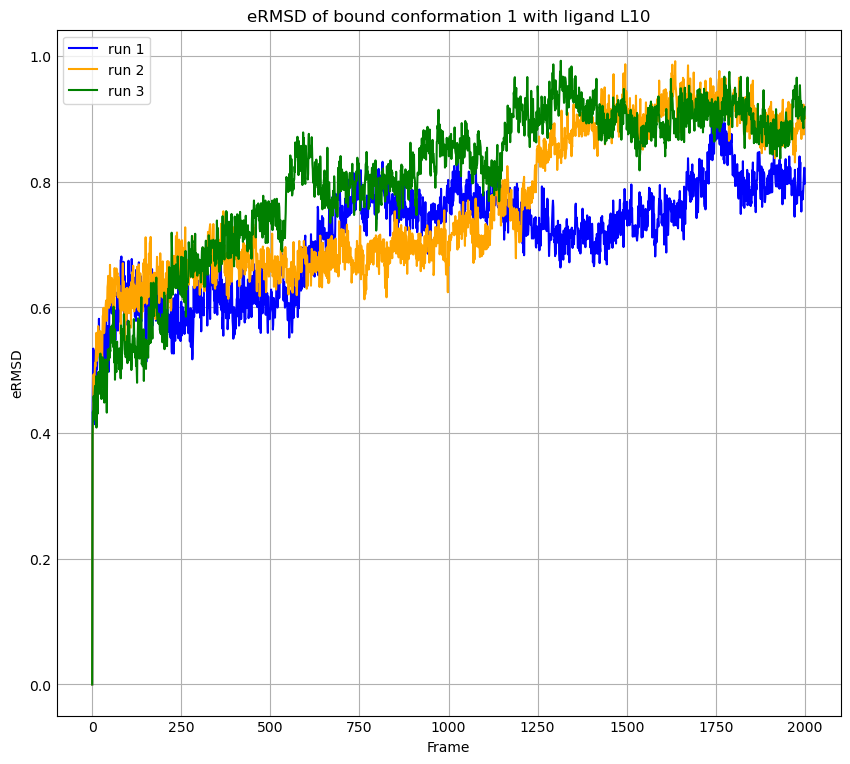

In [ ]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(8,7))

plt.xlabel("Frame")
plt.ylabel("eRMSD")
plt.plot(ermsd_1, color='blue')
plt.plot(ermsd_2, color='orange')
plt.plot(ermsd_3, color='green')
plt.legend(['run 1','run 2', 'run 3'])
plt.title('eRMSD of bound conformation 1 with ligand L10')

plt.show()

reaches plateau, which is still under good treshold, even though it shows an increase

### RMSD of the ligand

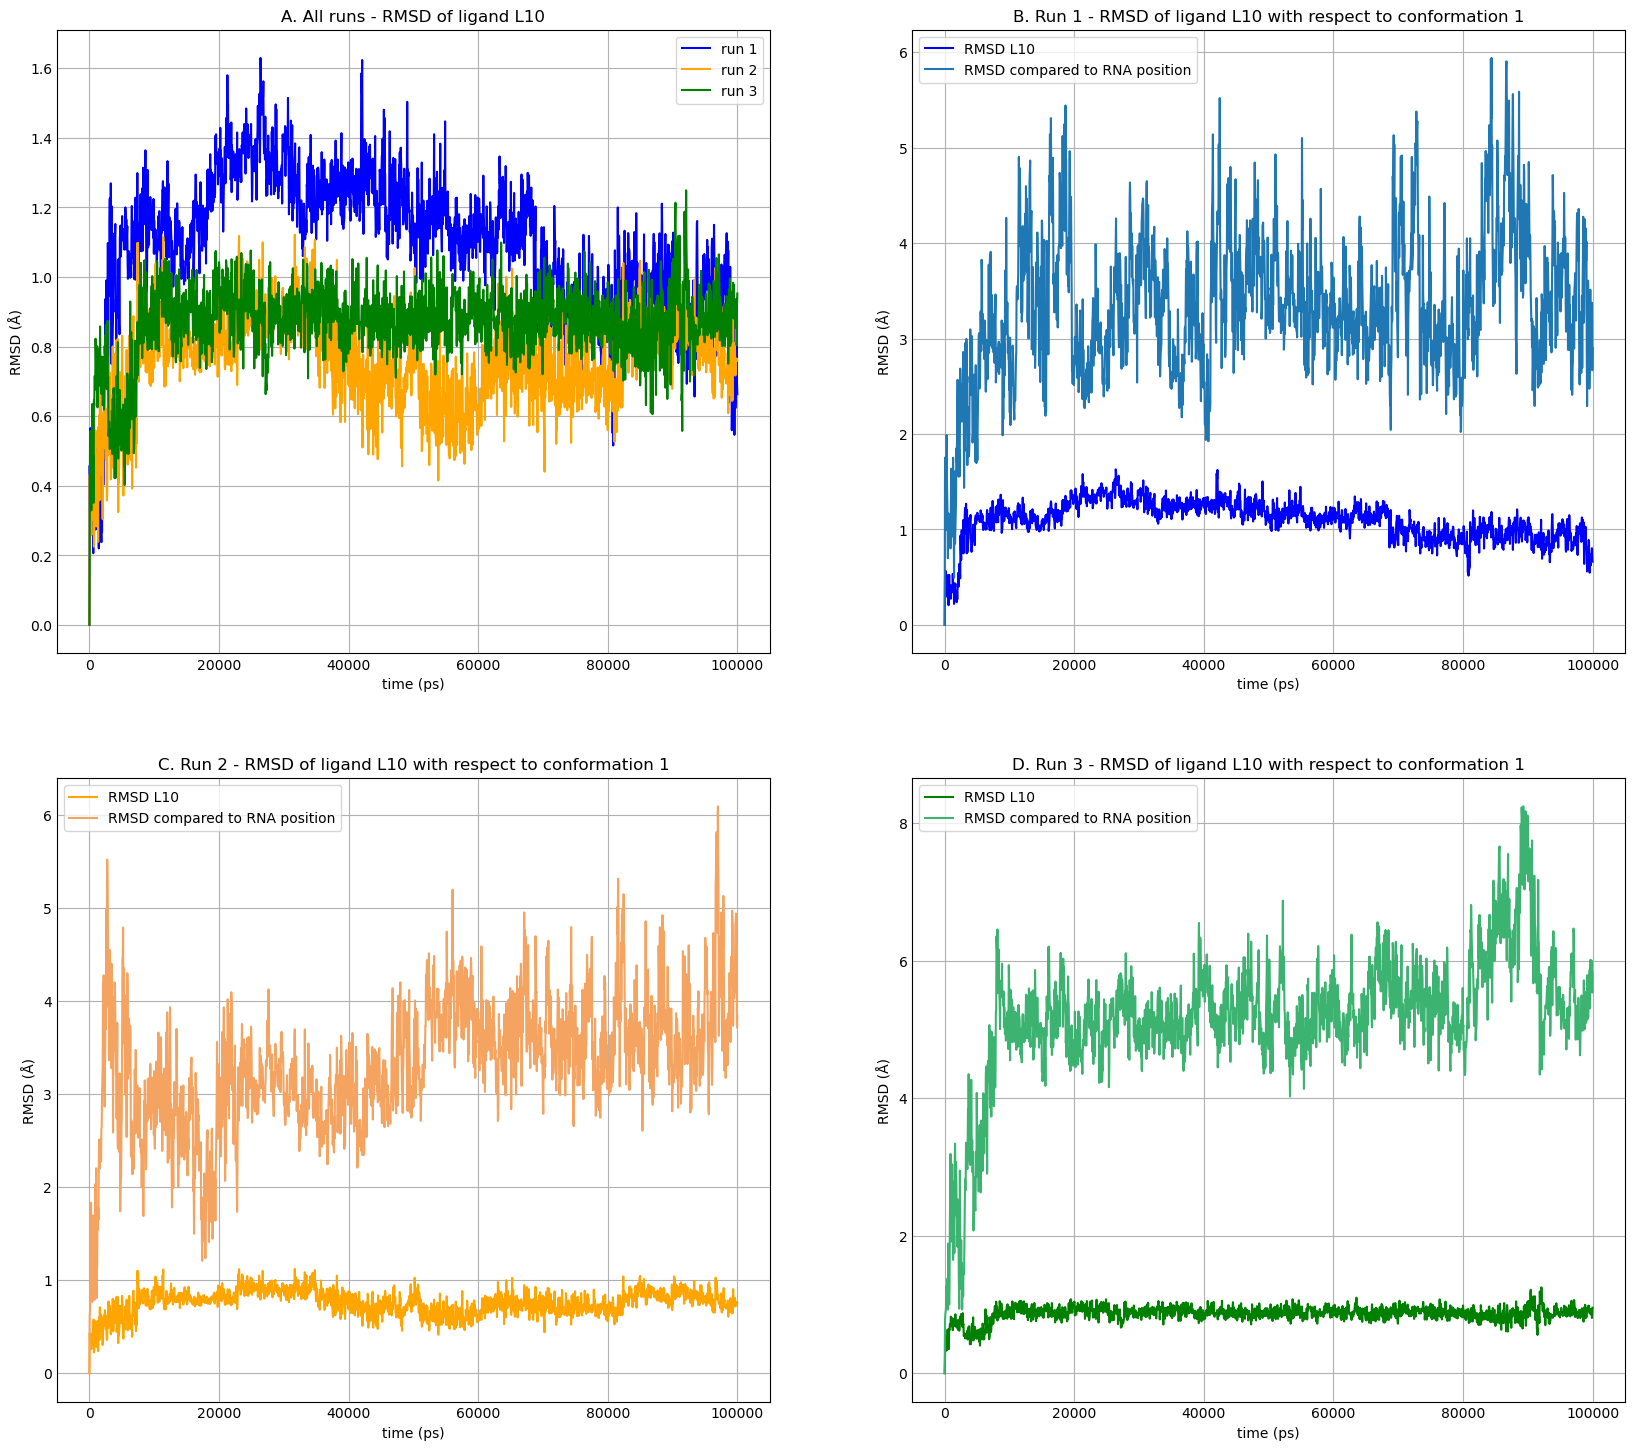

In [15]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(16,14))

plt.subplot(221)
plt.xlabel('time (ps)')
plt.ylabel('RMSD (Å)')
plt.plot(rmsd_L10_1.results["rmsd"][:,1],rmsd_L10_1.results["rmsd"][:,2], color="blue")
plt.plot(rmsd_L10_2.results["rmsd"][:,1],rmsd_L10_2.results["rmsd"][:,2], color="orange")
plt.plot(rmsd_L10_3.results["rmsd"][:,1],rmsd_L10_3.results["rmsd"][:,2], color="green")
plt.legend(['run 1','run 2', 'run 3'])
plt.title('A. All runs - RMSD of ligand L10')

plt.subplot(222)
plt.xlabel('time (ps)')
plt.ylabel('RMSD (Å)')
plt.plot(rmsd_L10_1.results["rmsd"][:,1],rmsd_L10_1.results["rmsd"][:,2], color="blue")
plt.plot(rmsd_lig_RNA_1.results["rmsd"][:,1],rmsd_lig_RNA_1.results["rmsd"][:,3], )
plt.legend(['RMSD L10','RMSD compared to RNA position',])
plt.title('B. Run 1 - RMSD of ligand L10 with respect to conformation 1')

plt.subplot(223)
plt.xlabel('time (ps)')
plt.ylabel('RMSD (Å)')
plt.plot(rmsd_L10_2.results["rmsd"][:,1],rmsd_L10_2.results["rmsd"][:,2], color="orange")
plt.plot(rmsd_lig_RNA_2.results["rmsd"][:,1],rmsd_lig_RNA_2.results["rmsd"][:,3], color='sandybrown')
plt.legend(['RMSD L10','RMSD compared to RNA position',])
plt.title('C. Run 2 - RMSD of ligand L10 with respect to conformation 1')

plt.subplot(224)
plt.xlabel('time (ps)')
plt.ylabel('RMSD (Å)')
plt.plot(rmsd_L10_3.results["rmsd"][:,1],rmsd_L10_3.results["rmsd"][:,2], color="green")
plt.plot(rmsd_lig_RNA_3.results["rmsd"][:,1],rmsd_lig_RNA_3.results["rmsd"][:,3], color='mediumseagreen')
plt.legend(['RMSD L10','RMSD compared to RNA position',])
plt.title('D. Run 3 - RMSD of ligand L10 with respect to conformation 1')

plt.show()

Compared to the L44, L10 stays closer to the RNA(values ar no more than 6 in the first to runs and go all the way to 8 in the last run)